# Atomic claim extractor — intrinsic eval report

Loads the outputs of `intrinsic_eval.py` and renders the headline summary table,
histograms, and worst-case examples for qualitative inspection.

Inputs (set via the `RESULTS_PREFIX` and `PREDICTIONS_PATH` constants below):
- `<prefix>_summary.json`
- `<prefix>_per_example.jsonl`
- `predicted_claims.jsonl` (for joining answer text into worst-N tables)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

HERE = Path.cwd() if Path.cwd().name == "atomic_claims" else Path("library_evals/atomic_claims")
RESULTS_PREFIX = HERE / "results"
PREDICTIONS_PATH = HERE / "predicted_claims.jsonl"

SUMMARY_PATH = RESULTS_PREFIX.parent / (RESULTS_PREFIX.name + "_summary.json")
PER_EXAMPLE_PATH = RESULTS_PREFIX.parent / (RESULTS_PREFIX.name + "_per_example.jsonl")

summary = json.loads(SUMMARY_PATH.read_text())
rows = [json.loads(line) for line in PER_EXAMPLE_PATH.read_text().splitlines() if line.strip()]
df = pd.DataFrame(rows)

preds_by_idx: dict[int, dict] = {}
if PREDICTIONS_PATH.exists():
    for line in PREDICTIONS_PATH.read_text().splitlines():
        if line.strip():
            r = json.loads(line)
            preds_by_idx[r.get("alce_index")] = r

print(f"loaded {len(df)} examples")
summary["config"]

loaded 50 examples


{'nli_model': 'cross-encoder/nli-deberta-v3-large',
 'threshold': 0.5,
 'metrics': ['atomicity',
  'coverage',
  'non_redundancy',
  'sentence_claim_coverage'],
 'coverage_topk': 3,
 'input': '/home/wallat/attribution-eval/library_evals/atomic_claims/predicted_claims.jsonl'}

## Summary table

In [ ]:
rows_table = []
for label, key in [
    ("Faithfulness (mean ent.)", "faithfulness_mean"),
    ("Faithful fraction (>= thr)", "faithful_fraction"),
    ("Coverage (sentence-level)", "coverage_sentence"),
    ("Coverage (whole-answer)", "coverage_whole"),
    ("Atomicity", "atomicity"),
    ("Non-redundancy", "non_redundancy"),
]:
    s = summary[key]
    rows_table.append(
        {"metric": label, "mean": s["mean"], "std": s["std"], "% >= 0.9": s["frac_ge_0_9"]}
    )
summary_df = pd.DataFrame(rows_table).set_index("metric")
summary_df.style.format({"mean": "{:.3f}", "std": "{:.3f}", "% >= 0.9": "{:.3f}"})

,mean,std,% >= 0.9
metric,,,
Faithfulness (mean ent.),0.802,0.230,0.500
Faithful fraction (>= thr),0.812,0.248,0.600
Coverage (sentence-level),0.214,0.165,0.000
Coverage (whole-answer),0.000,0.000,0.000
Atomicity,0.940,0.105,0.700
Non-redundancy,0.946,0.107,0.800


: 

: 

## Distributions

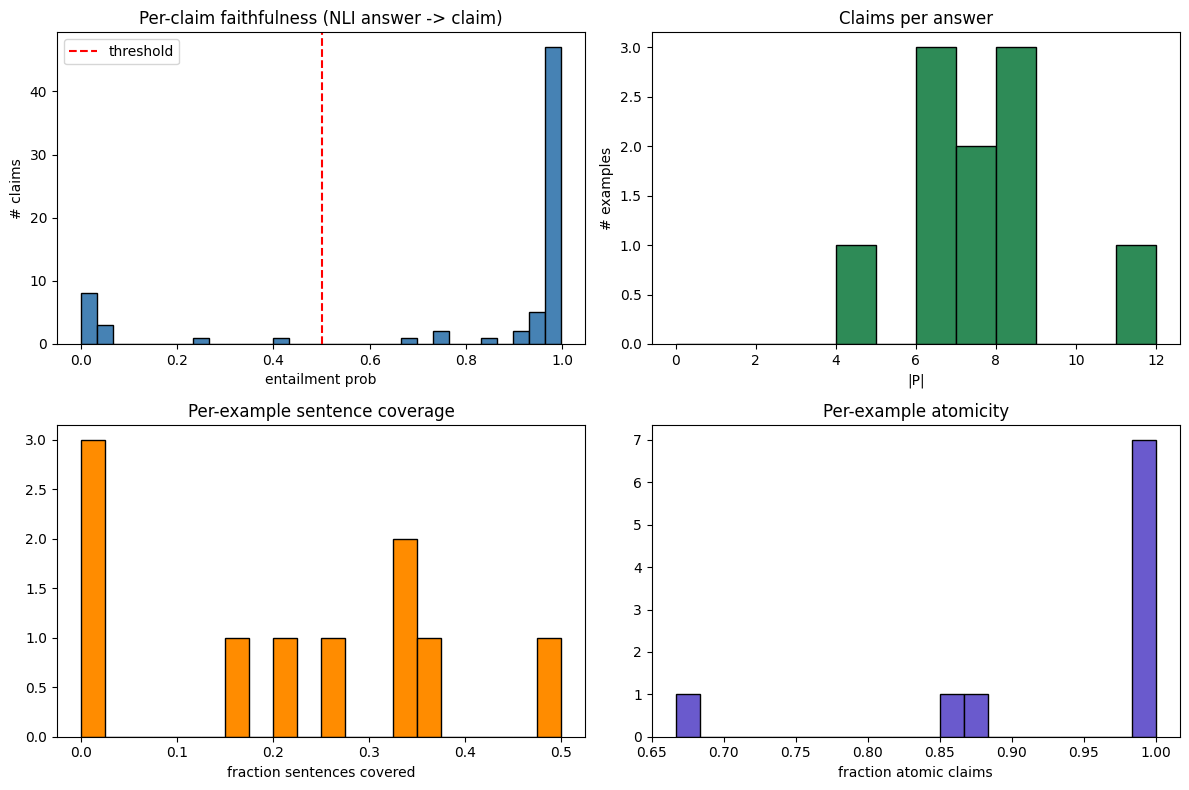

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

all_per_claim = [p for row in df["per_claim_faithfulness"] for p in row]
axes[0, 0].hist(all_per_claim, bins=30, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Per-claim faithfulness (NLI answer -> claim)")
axes[0, 0].set_xlabel("entailment prob")
axes[0, 0].set_ylabel("# claims")
axes[0, 0].axvline(0.5, color="red", linestyle="--", label="threshold")
axes[0, 0].legend()

axes[0, 1].hist(df["n_claims"], bins=range(0, int(df["n_claims"].max()) + 2),
                color="seagreen", edgecolor="black")
axes[0, 1].set_title("Claims per answer")
axes[0, 1].set_xlabel("|P|")
axes[0, 1].set_ylabel("# examples")

axes[1, 0].hist(df["coverage_sentence"], bins=20, color="darkorange", edgecolor="black")
axes[1, 0].set_title("Per-example sentence coverage")
axes[1, 0].set_xlabel("fraction sentences covered")

axes[1, 1].hist(df["atomicity"], bins=20, color="slateblue", edgecolor="black")
axes[1, 1].set_title("Per-example atomicity")
axes[1, 1].set_xlabel("fraction atomic claims")

plt.tight_layout()
plt.show()

## Worst examples — qualitative inspection

In [ ]:
def show_worst(metric: str, k: int = 5) -> None:
    print(f"\n=== Worst {k} by {metric} ===")
    worst = df.nsmallest(k, metric)
    for _, row in worst.iterrows():
        idx = row["alce_index"]
        pred = preds_by_idx.get(idx, {})
        print(f"\n--- alce_index={idx}  {metric}={row[metric]:.3f}  n_claims={row['n_claims']} ---")
        print(f"Q: {pred.get('question', '')[:200]}")
        print(f"A: {pred.get('answer', '')[:500]}")
        for i, c in enumerate(pred.get("predicted_claims", [])):
            faith = row["per_claim_faithfulness"][i] if i < len(row["per_claim_faithfulness"]) else None
            atomic = row["per_claim_atomic"][i] if i < len(row["per_claim_atomic"]) else None
            print(f"  [{i}] faith={faith:.2f} atomic={atomic} :: {c}" if faith is not None else f"  [{i}] {c}")

show_worst("faithfulness_mean", 5)
show_worst("coverage_sentence", 5)


=== Worst 5 by faithfulness_mean ===

--- alce_index=142  faithfulness_mean=0.261  n_claims=8 ---
Q: Who wrote the song mary did you know?
A: Mark Lowry wrote the lyrics to the song "Mary, Did You Know?" in 1984, while asked to write a script for a church Christmas play, and the music was written by Buddy Greene [1][2]. The song was originally recorded by Michael English in 1991 and has since become a popular Christmas song [1]. Mark Lowry wrote the song after an accident that left him with eleven broken bones [3]. The lyrics are based on Lowry's questions to Mary, the mother of Jesus, about her experiences at the time of Jesus' birth
  [0] faith=0.02 atomic=True :: Mark Lowry wrote the lyrics to the song 'Mary, Did You Know?'
  [1] faith=0.05 atomic=True :: The music was written by Buddy Greene.
  [2] faith=0.06 atomic=True :: The song was originally recorded by Michael English in 1991.
  [3] faith=0.93 atomic=True :: The song has become a popular Christmas song.
  [4] faith=0.00 ato

: 

: 

## Correlations between metrics

Quick sanity check: faithfulness and atomicity should be roughly independent;
non-redundancy should anti-correlate with claim count if the extractor over-splits.

In [ ]:
cols = [
    "n_claims",
    "faithfulness_mean",
    "faithful_fraction",
    "coverage_sentence",
    "coverage_whole",
    "atomicity",
    "non_redundancy",
]
df[cols].corr().round(2)

,n_claims,faithfulness_mean,faithful_fraction,coverage_sentence,coverage_whole,atomicity,non_redundancy
n_claims,1.00,0.01,0.07,-0.57,NaN,0.14,-0.10
faithfulness_mean,0.01,1.00,0.99,-0.47,NaN,0.07,0.32
faithful_fraction,0.07,0.99,1.00,-0.43,NaN,0.21,0.33
coverage_sentence,-0.57,-0.47,-0.43,1.00,NaN,0.22,-0.09
coverage_whole,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atomicity,0.14,0.07,0.21,0.22,NaN,1.00,0.08
non_redundancy,-0.10,0.32,0.33,-0.09,NaN,0.08,1.00


: 

: 